In [1]:
import pandas as pd  # Para trabajar con dataframes y manipular datos
import numpy as np  # Para cálculos numéricos
import matplotlib.pyplot as plt  # Para generar gráficos
from sklearn.manifold import TSNE  # Para reducción de dimensionalidad con t-SNE
from pathlib import Path  # Para manejar rutas de archivos de forma más limpia
from sklearn.preprocessing import StandardScaler  # Herramienta de normalización
import seaborn as sns

In [2]:
#Ruta al archivo local 
# Como el script está en la misma carpeta que el .txt, basta con:
file_path = Path("data_banknote_authentication.txt")

col_names = ["varianza", "sesgo", "cúrtosis", "entropía", "clase"]

df = pd.read_csv(
    file_path,
    header=None,        # El fichero NO trae cabecera
    names=col_names     # Asignamos los nombres de columna
)

df

,varianza,sesgo,cúrtosis,entropía,clase
0,3.62160,8.66610,-2.8073,-0.44699,0
1,4.54590,8.16740,-2.4586,-1.46210,0
2,3.86600,-2.63830,1.9242,0.10645,0
3,3.45660,9.52280,-4.0112,-3.59440,0
4,0.32924,-4.45520,4.5718,-0.98880,0
...,...,...,...,...,...
1367,0.40614,1.34920,-1.4501,-0.55949,1
1368,-1.38870,-4.87730,6.4774,0.34179,1
1369,-3.75030,-13.45860,17.5932,-2.77710,1
1370,-3.56370,-8.38270,12.3930,-1.28230,1


In [3]:
#Contamos cuántos registros hay de cada clase (0 = auténtico, 1 = falsificado)
df.clase.value_counts()

clase
0    762
1    610
Name: count, dtype: int64

Podemos observar que hay 762 billetes verdaderos y 610 falsos en el dataset

In [5]:
#vemos un resumen estadistico
df.describe()

,varianza,sesgo,cúrtosis,entropía,clase
count,1372.000000,1372.000000,1372.000000,1372.000000,1372.000000
mean,0.433735,1.922353,1.397627,-1.191657,0.444606
std,2.842763,5.869047,4.310030,2.101013,0.497103
min,-7.042100,-13.773100,-5.286100,-8.548200,0.000000
25%,-1.773000,-1.708200,-1.574975,-2.413450,0.000000
50%,0.496180,2.319650,0.616630,-0.586650,0.000000
75%,2.821475,6.814625,3.179250,0.394810,1.000000
max,6.824800,12.951600,17.927400,2.449500,1.000000


Del resumen estadístico podemos obervar lo siguiente:
### Interpretación rápida de las estadísticas ( `describe()` )

| Variable      | Rango y tendencia | Dispersión | Lectura práctica |
|---------------|------------------|------------|------------------|
| **Varianza**  | -7.04 → 6.82, mediana ≈ 0.50, media 0.43 (ligeramente > 0) | σ = 2.84 | Valores tanto negativos como positivos; el 50 % cae entre -1.77 y 2.82. Señales de dispersión alta ⇒ conviene estandarizar antes de modelos sensibles a la escala. |
| **Sesgo**     | -13.77 → 12.95, mediana 2.32, media 1.92 | σ = 5.90 | Amplio rango y varianza muy grande: distribución asimétrica con colas pronunciadas. Puede influir fuerte en técnicas basadas en distancias si no se normaliza. |
| **Cúrtosis**  | -5.29 → 17.93, mediana 0.62, media 1.40 | σ = 4.31 | Predominan valores cercanos a 0 pero existen picos altos (kurtosis positiva) que indican colas pesadas, potencialmente útiles para separar clases. |
| **Entropía**  | -8.55 → 2.45, mediana -0.59, media -1.19 | σ = 2.10 | Distribución centrada en negativos; 75 % ya está por debajo de 0.40. Sesgo hacia la izquierda sugiere que la mayoría de billetes tiene entropía baja. |
| **Clase**     | 0 → 1, media 0.445 | σ = 0.50 | Variable binaria: ~44 % billetes falsificados y ~56 % auténticos; ligero desbalance que conviene tener presente al evaluar modelos. |

En resumen, el análisis estadístico muestra que las variables numéricas presentan diferentes rangos y dispersión (dadas sus desviaciones estándar), especialmente `sesgo` y `cúrtosis`. Esto destaca la importancia de estandarizar los datos antes de aplicar algoritmos como t-SNE o clustering para asegurar que todas las variables tengan el mismo peso en el análisis. Además, la variable `clase` muestra un balance aceptable entre las clases, lo que facilita la interpretación de las visualizaciones y el análisis de patrones en los datos.


<Axes: >

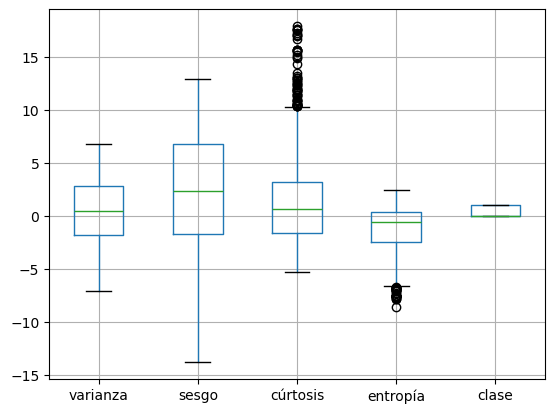

In [8]:
# Muestra un diagrama de cajas para cada variable numérica, destacando la mediana, el rango intercuartílico y posibles outliers
df.boxplot()

El boxplot confirma que las variables tienen diferentes grados de dispersión y presencia de outliers, especialmente en **cúrtosis**, mientras que **sesgo** tiene un rango intercuartílico amplio. Esto refuerza la importancia de estandarizar los datos antes de aplicar algoritmos, para que ninguna variable domine el análisis debido a su escala o dispersión.

In [10]:
#Estandarización de datos
X = df.drop(columns="clase")# 4 columnas numéricas: varianza, sesgo, cúrtosis, entropía
y = df["clase"]# Etiqueta binaria: 0 = auténtico, 1 = falsificado

#Crear el objeto escalador
scaler = StandardScaler()# Centra cada feature y lo divide por su desviación estándar

# Ajustar el escalador a X y transformar los datos
#     - fit(): calcula media y desviación estándar de cada columna
#     - transform(): aplica (x - μ) / σ
#     - fit_transform() hace ambos pasos en una sola llamada
X_std = scaler.fit_transform(X)     # array (1372, 4)
# Ahora X_std está listo para algoritmos basados en distancia.

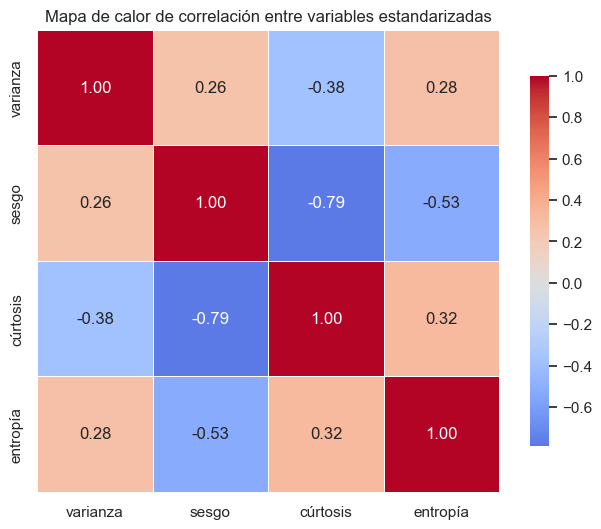

In [11]:
# Creamos un DataFrame con los datos estandarizados y la etiqueta
df_std = pd.DataFrame(X_std, columns=X.columns)
df_std["clase"] = y.values  # 0 = auténtico, 1 = falsificado

# Calculamos la matriz de correlación de las variables numéricas estandarizadas
correlation_matrix = df_std.drop(columns="clase").corr()

# Configuramos el estilo y tamaño de la figura
plt.figure(figsize=(8, 6))
sns.set(style="whitegrid")

# Dibujamos el mapa de calor de correlación
sns.heatmap(
    correlation_matrix,
    annot=True,            # Mostrar valores numéricos en las celdas
    fmt=".2f",             # Formato de dos decimales
    cmap="coolwarm",       # Paleta de colores
    center=0,              # Centrar la escala de colores en 0
    square=True,           # Formato cuadrado
    linewidths=0.5,        # Líneas de separación
    cbar_kws={"shrink": 0.8}  # Ajustar el tamaño de la barra de color
)
plt.title("Mapa de calor de correlación entre variables estandarizadas")
plt.show()

## Conclusiones del Mapa de Calor de Correlación

El mapa de calor de correlación muestra que:

- Existe una fuerte correlación negativa entre `sesgo` y `cúrtosis` (**-0.79**), lo que indica que estas dos variables no son completamente independienión.
  
- `sesgo` también presenta una correlación negativa moderada con `entropía` (**-0.53**), mientras que `cúrtosis` y `entropía` tienen una correlación positiva moderada (**0.32**). Estas relaciones sugieren que algunas variables están relacionadas entre sí de manera indirecta.

- `varianza`, por su parte, muestra correlaciones débiles con las demás variables (entre **0.26 y 0.38**), lo cual sugiere que podría aportar información adicional e independiente en el análisis y en el modelo.

En conjunto, estas correlaciones ayudan a identificar relaciones importantes y redundancias potenciales entre las.sificados.


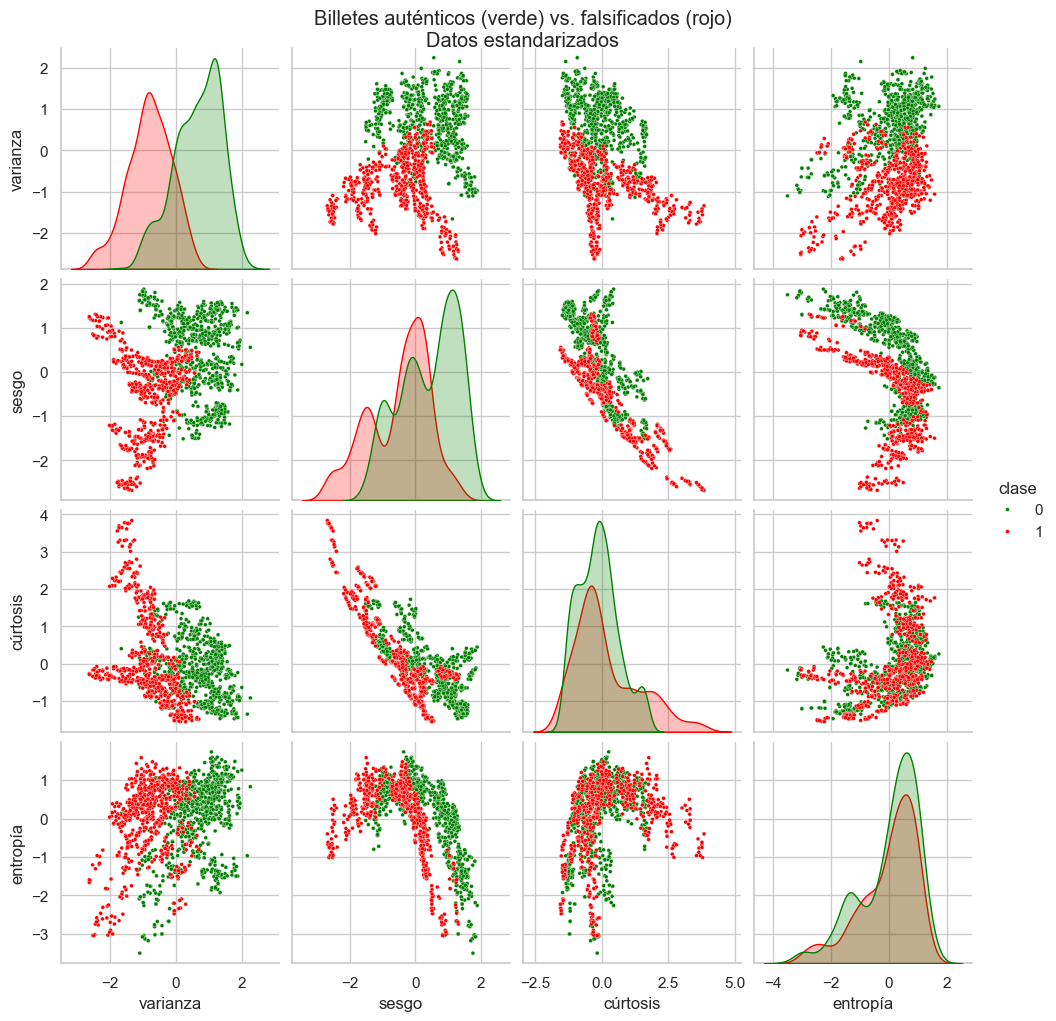

In [13]:
#observamos visualmente las relaciones entre las variables numéricas estandarizadas del dataset. 
# Configuramos la paleta de colores para el pairplot
palette = {0: "green", 1: "red"}

# Dibujamos el pairplot
sns.pairplot(
    df_std,
    hue="clase",
    palette=palette,
    plot_kws={"s": 8}
)

# Título del pairplot
plt.suptitle(
    "Billetes auténticos (verde) vs. falsificados (rojo)\nDatos estandarizados",
    y=1.02
)
plt.show()

Podemos notar como por ejemplo en sesgo vs entropia o curtosis vs entropia, que no existe relacion lineal. Es importante tomar esto en cuenta para elegir el modelo a utilizar,dado que no todas las variables tienen relacion lineal elegiremos un modelo o algoritmo que sea capaz de trabajar correctamente con este tipo de datos, en este caso, el algotirmo de aprendizaje no supervisado T-SNE. 

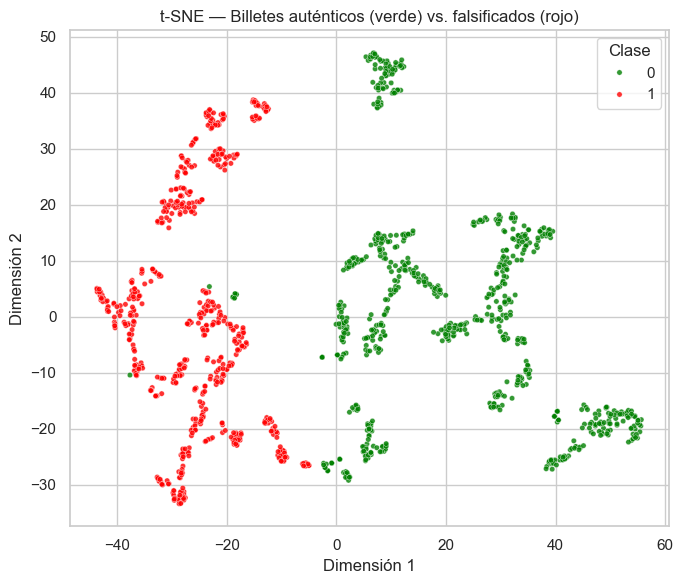

In [15]:
# Instanciar t-SNE (parámetros habituales del cuaderno original)
tsne = TSNE(
    n_components=2,        # proyectamos a 2 dimensiones
    perplexity=30,         # tamaño efectivo de la vecindad
    learning_rate="auto",  # ajuste interno recomendado
    init="random",         # inicialización aleatoria
    random_state=42        # reproducibilidad
)

# Ajustar y transformar los datos estandarizados
X_tsne = tsne.fit_transform(X_std)    # ndarray  (1372, 2)

# Convertir a DataFrame y añadir la etiqueta
df_tsne = pd.DataFrame(
    {
        "Dim1": X_tsne[:, 0],
        "Dim2": X_tsne[:, 1],
        "clase": y.values          # 0 = auténtico, 1 = falsificado
    }
)

#Visualizar la proyección 2-D coloreando por clase
palette = {0: "green", 1: "red"}      # auténtico → verde, falsificado → rojo
plt.figure(figsize=(7, 6))
sns.scatterplot(
    data=df_tsne,
    x="Dim1", y="Dim2",
    hue="clase",# indica a Seaborn que use la columna "clase" para asignar un color a cada punto.
    palette=palette,
    s=15, alpha=0.8 #tamaño y transparencia de los puntos respectivamente
)
plt.title("t-SNE — Billetes auténticos (verde) vs. falsificados (rojo)")
plt.xlabel("Dimensión 1"); plt.ylabel("Dimensión 2")
plt.legend(title="Clase", loc="best")
plt.tight_layout()
plt.show()


El t-SNE muestra dos grupos bien separados: verdes (auténticos) a la derecha y rojos (falsos) a la izquierda, con casi ningún solapamiento. Esto indica que las cuatro variables distinguen eficazmente las clases y que cualquier algoritmo de clustering o clasificación debería funcionar muy bien en este conjunto